## Theoretical pacing figure

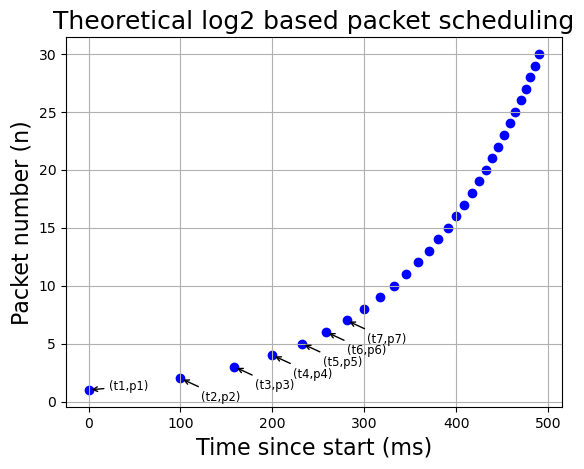

In [39]:
def packet_scheduling(rtt):
    y = [x for x in range(1, 31)]
    x = [ rtt * np.log2(y) for y in y ]
    x = [ms * 1000 for ms in x]
    
    labels = ["(t1,p1)", "(t2,p2)", "(t3,p3)", "(t4,p4)", "(t5,p5)", "(t6,p6)", "(t7,p7)"]
    indicies = [1, 2, 3 ,4, 5, 6]
    
    plt.annotate(
        labels[0],
        (x[0], y[0]),
        xytext=(15, 0),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
        fontsize="small"
    )
    
    for i in indicies:
        plt.annotate(
            labels[i],
            (x[i], y[i]),
            xytext=(15, -16),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->"),
            fontsize="small"
        )
    
    #for xi, yi, label in zip(x, y, labels):
    #    plt.text(xi, yi, label)
        
    plt.title("Theoretical log2 based packet scheduling", fontsize=18)
    plt.xlabel("Time since start (ms)", fontsize=16)
    plt.ylabel("Packet number (n)", fontsize=16)
    
    plt.scatter(x, y, color='blue', label='Individual packet scheduling')
    
    plt.grid()
    plt.show()
    
packet_scheduling(0.1)
    

## Log2 calculation, exact copy of kernel code, translated to Python

NameError: name 'np' is not defined

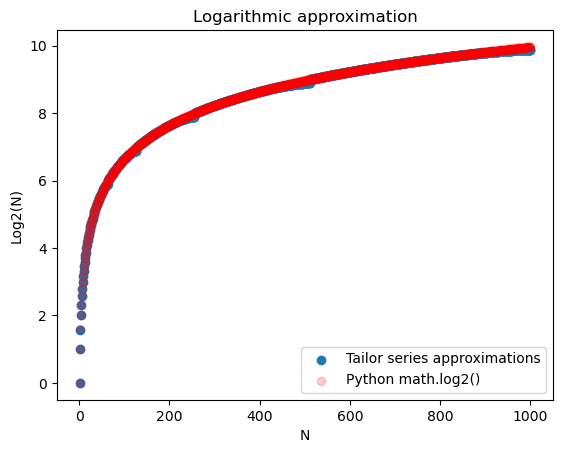

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np

LOG2_FRAC_BITS = 32
INV_LN2_Q32 = 6196328018  # q32_t
S64_MIN = -(1 << 63)

MASK64 = (1 << 64) - 1

def to_s64(x: int) -> int:
    """Wrap to signed 64-bit two's-complement."""
    x &= MASK64
    return x - (1 << 64) if x & (1 << 63) else x

def div_s64(a: int, b: int) -> int:
    """Signed division with truncation toward zero (like C)."""
    if b == 0:
        raise ZeroDivisionError
    return math.trunc(a / b)

def ilog2_u64(x: int) -> int:
    # kernel ilog2(0) is undefined; caller avoids x==0.
    return x.bit_length() - 1

def normalize_to_q32(x: int, e: int) -> int:
    if e >= LOG2_FRAC_BITS:
        return x >> (e - LOG2_FRAC_BITS)
    else:
        return x << (LOG2_FRAC_BITS - e)

def mul_q32(a: int, b: int) -> int:
    """(a*b)>>32 with 128-bit intermediate; wrap result to s64."""
    return to_s64((a * b) >> LOG2_FRAC_BITS)

def log2_1p_t_q32(t_q32: int) -> int:
    t2 = mul_q32(t_q32, t_q32)
    t3 = mul_q32(t2, t_q32)
    t4 = mul_q32(t3, t_q32)
    t5 = mul_q32(t4, t_q32)
    t6 = mul_q32(t5, t_q32)

    ln1p_q32 = to_s64(
        t_q32
        - (t2 >> 1)
        + div_s64(t3, 3)
        - (t4 >> 2)
        + div_s64(t5, 5)
        - div_s64(t6, 6)
    )

    return mul_q32(ln1p_q32, INV_LN2_Q32)

def klog2_q32(x: int, rtt: int) -> int:
    if x == 0:
        return S64_MIN  # "minus infinity"

    e = ilog2_u64(x)
    m_q32 = normalize_to_q32(x, e)
    t_q32 = to_s64(m_q32 - (1 << LOG2_FRAC_BITS))  # m_q32 - 1.0 in Q32

    frac = log2_1p_t_q32(t_q32)
    return to_s64((e << LOG2_FRAC_BITS) + frac)

def log_normal(x: int, rtt: int):
    return math.log2(x)

def count_packets_in_last_in_interval(ys, start_time, end_time):
    counter = 0
    
    for packet in ys:
        if packet > end_time:
            break
        
        if packet >= start_time:
            counter += 1
            
    return counter

if __name__ == "__main__":
    rtt = 30_000 # 30 ms
    N = 1000
    xs = list(range(1, N + 1))

    # Plot log values only (convert Q32 to float for readability)
    ys = [(klog2_q32(x, rtt) / float(1 << LOG2_FRAC_BITS)) for x in xs]    
    ys2 = [log_normal(x, rtt) for x in xs]

    plt.figure()
    plt.scatter(xs, ys, label="Tailor series approximations")
    plt.scatter(xs, ys2, color="red", label="Python math.log2()", alpha=0.2)
    
    plt.title("Logarithmic approximation")
    plt.legend()
    plt.xlabel("N")
    plt.ylabel("Log2(N)")
    plt.xticks(np.arange(0, 1200, 200))
    plt.grid(True)
    plt.show()

## Rate calculation, exact copy of kernel code translated to Python

In [ ]:
import math
import matplotlib.pyplot as plt

LOG2_FRAC_BITS = 32
INV_LN2_Q32 = 6196328018  # q32_t
S64_MIN = -(1 << 63)

MASK64 = (1 << 64) - 1

def to_s64(x: int) -> int:
    """Wrap to signed 64-bit two's-complement."""
    x &= MASK64
    return x - (1 << 64) if x & (1 << 63) else x

def div_s64(a: int, b: int) -> int:
    """Signed division with truncation toward zero (like C)."""
    if b == 0:
        raise ZeroDivisionError
    return math.trunc(a / b)

def div_u64(a: int, b: int) -> int:
    """Unsigned (non-negative) integer division (like C)."""
    if b == 0:
        raise ZeroDivisionError
    return a // b

def ilog2_u64(x: int) -> int:
    # kernel ilog2(0) is undefined; caller avoids x==0.
    return x.bit_length() - 1

def normalize_to_q32(x: int, e: int) -> int:
    if e >= LOG2_FRAC_BITS:
        return x >> (e - LOG2_FRAC_BITS)
    else:
        return x << (LOG2_FRAC_BITS - e)

def mul_q32(a: int, b: int) -> int:
    # (a*b)>>32 with 128-bit intermediate; wrap result to s64
    return to_s64((a * b) >> LOG2_FRAC_BITS)

def log2_1p_t_q32(t_q32: int) -> int:
    t2 = mul_q32(t_q32, t_q32)
    t3 = mul_q32(t2, t_q32)
    t4 = mul_q32(t3, t_q32)
    t5 = mul_q32(t4, t_q32)
    t6 = mul_q32(t5, t_q32)

    ln1p_q32 = to_s64(
        t_q32
        - (t2 >> 1)
        + div_s64(t3, 3)
        - (t4 >> 2)
        + div_s64(t5, 5)
        - div_s64(t6, 6)
    )

    return mul_q32(ln1p_q32, INV_LN2_Q32)

def klog2_q32(x: int) -> int:
    if x == 0:
        return S64_MIN  # "minus infinity"

    e = ilog2_u64(x)
    m_q32 = normalize_to_q32(x, e)
    t_q32 = to_s64(m_q32 - (1 << LOG2_FRAC_BITS))  # m_q32 - 1.0 in Q32

    frac = log2_1p_t_q32(t_q32)
    return to_s64((e << LOG2_FRAC_BITS) + frac)

def get_logbased_pacing_rate(packet_num: int, smooth_rtt_us: int) -> int:
    if packet_num < 1:
        packet_num = 1
        
    log_np1 = klog2_q32(packet_num + 1)

    return log_np1 * smooth_rtt_us

# --- Plot demo ---
if __name__ == "__main__":
    smooth_rtt = 30_000  # 30 ms
    N = 1000

    xs = list(range(1, N + 1))
    ys = [get_logbased_pacing_rate(n, smooth_rtt) / 1000 for n in xs]

    plt.figure()
    plt.scatter(ys, xs)
    plt.title(f"Packet scheduling logarithmic pacing")
    plt.xlabel("Time since start (ms)")
    plt.ylabel("Packet number")
    plt.grid(True)
    plt.show()